## Aerodynamic Shape Optimization

### Minimum Induced Drag (Elliptical Wing)

Let's do some aerodynamic shape optimization, using a classic problem:

Find the wing shape that minimizes induced drag, with the following assumptions:

* A fixed lift
* A fixed wing area
* A fixed wing span
* An untwisted, uncambered, thin, planar wing
* Inviscid, incompressible, irrotational, steady flow

The answer, as any good introductory aerodynamics textbook will teach, is a wing with an elliptical lift distribution. For an untwisted wing (in small angle approximation), this corresponds to an elliptical chord distribution.

Let's pose the problem in AeroSandbox, using the `VortexLatticeMethod` flow solver.

In [15]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

In [16]:
opti = asb.Opti()  # Initialize an optimization environment.

N = 30  # Number of chord sections to optimize

# The y-locations (i.e. span locations) of each section. Note that the span is fixed.
section_y = np.linspace(0, 2.785, N)
# Using `linspace` gives us evenly spaced sections along the span.

## Définition dérive

### Variables

In [17]:
# Independent twist variables at each section (nonlinear distribution)
twists = opti.variable(init_guess=np.zeros(N))  # All twists initially guessed as "0".

## Import section

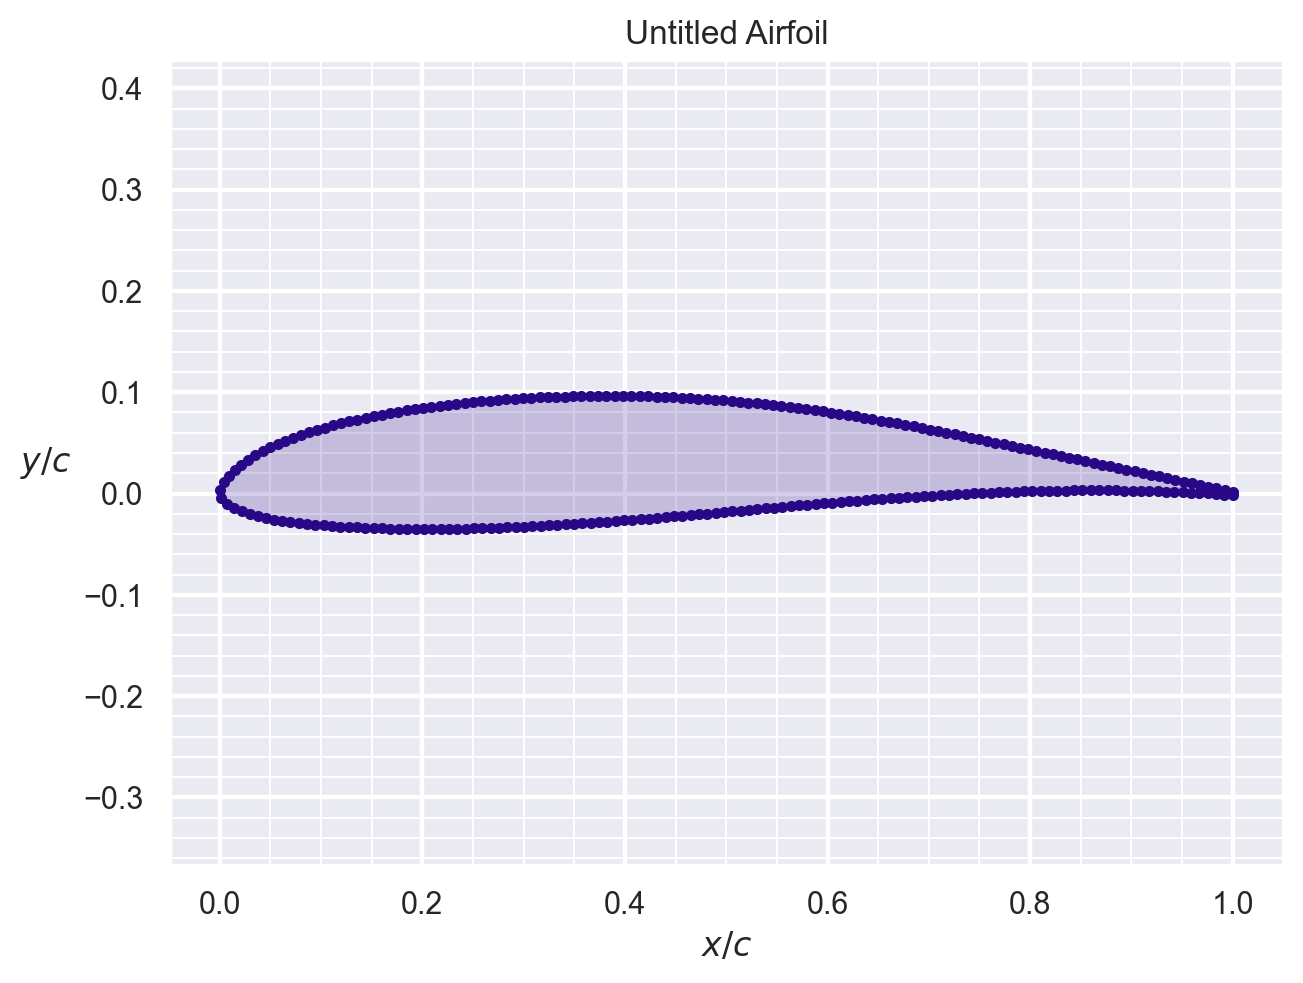

In [18]:
section = asb.Airfoil(coordinates= r'C:\Users\antoine.vittet\Desktop\MC2_60_6101_1.dat')
section.draw()

In [19]:
section.generate_polars(
    xfoil_kwargs={'xfoil_command': r'C:\Users\antoine.vittet\Documents\bdToolbox\soft\xfoil.exe'}
)

Running XFoil to generate polars for Airfoil 'Untitled'::   0%|          | 0/12 [00:00<?, ?it/s]c:\Users\antoine.vittet\Documents\bdToolbox\.venv\lib\site-packages\aerosandbox\aerodynamics\aero_2D\xfoil.py:668: UserWarning: XFoil run timed out!
If this was not expected, try increasing the `timeout` parameter
when you create this AeroSandbox XFoil instance.
  output = self._run_xfoil(
Running XFoil to generate polars for Airfoil 'Untitled':: 100%|██████████| 12/12 [01:10<00:00,  5.86s/it]


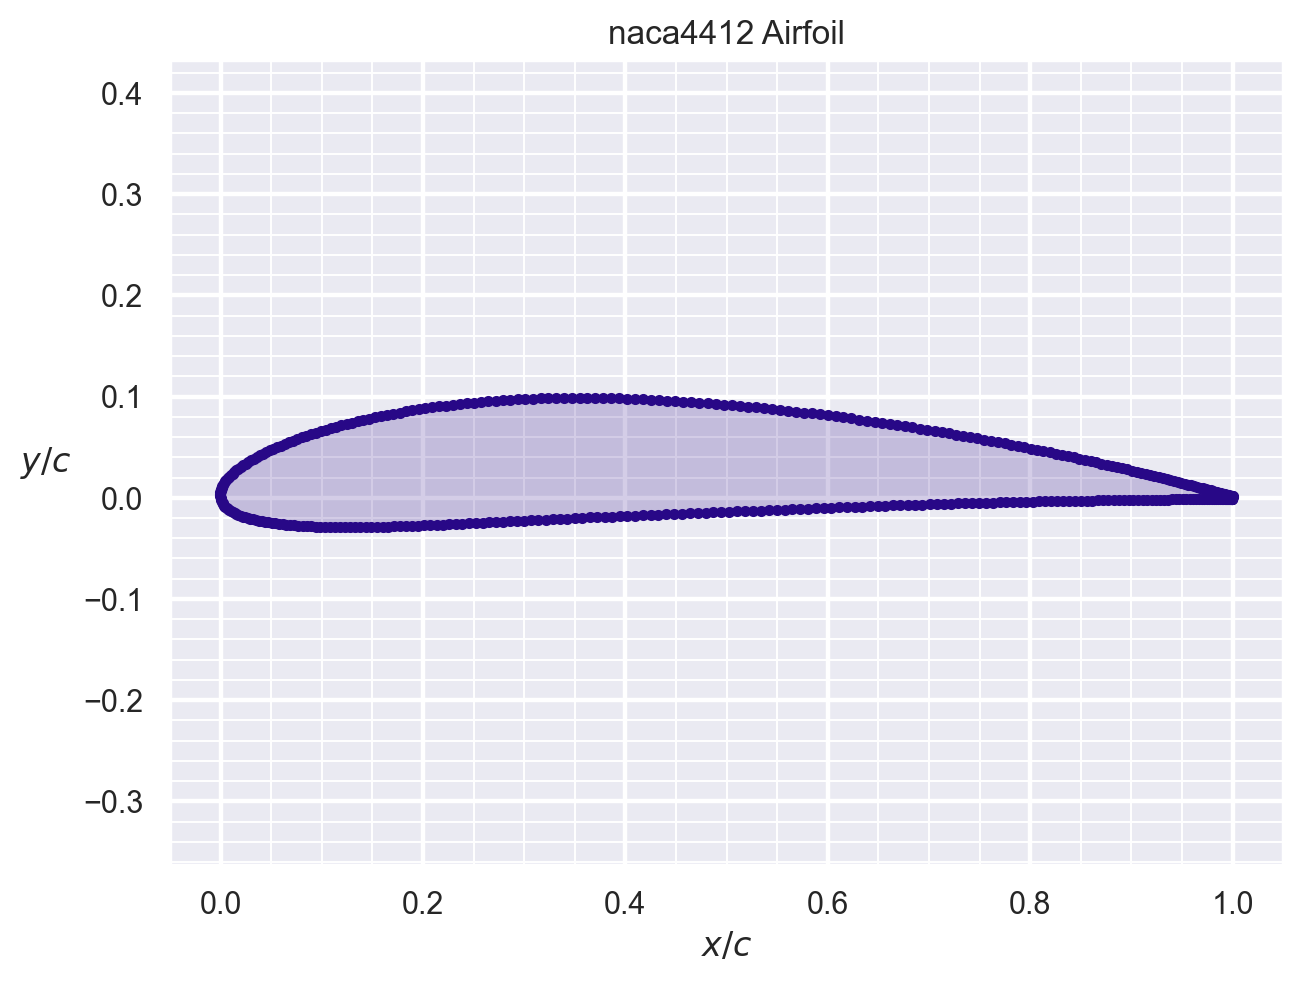

In [3]:
naca_section = asb.Airfoil("naca4412")
naca_section.draw()

In [21]:
wing = asb.Wing(
    symmetric=True,
    xsecs=[
        asb.WingXSec(
            xyz_le=[
                0,  # This keeps the quarter-chord-line straight.
                section_y[i],  # Our (known) span locations for each section.
                0,
            ],
            chord=1,
            twist=twists[i], #0 OR twists[i]
            airfoil = section
        )
        for i in range(N)
    ],
)

airplane = asb.Airplane(  # Make an airplane object containing only this wing.
    wings=[wing]
)

In [ ]:
from pyvista.trame.jupyter import launch_server
await launch_server().ready
airplane.draw() # doesn't work if we use `twists[i]` as the twist value, since `twists` is an optimization variable, not a numeric value. 

TypeError: object of type 'MX' has no len()

## VLM method setup

In [22]:
# alpha = opti.variable(init_guess=np.radians(5), lower_bound= 0, upper_bound=15)  # Angle of attack, also to be optimized.
alpha = 0 # We could chose to set alpha to a different value for example to the typical leeway angle at certain navigation case

op_point = asb.OperatingPoint(
    velocity=1,  # Some fixed velocity; doesn't matter since we're working nondimensionally.
    alpha=alpha,
)

vlm = asb.VortexLatticeMethod(
    airplane=airplane,
    op_point=op_point,
    spanwise_resolution=1,
    chordwise_resolution=8,
)

aero = vlm.run()

## Contraintes

In [23]:
opti.subject_to(
    [  # Constraints for nonlinear twist distribution
        twists > -20,  # Lower bound for all twists
        twists < 20,  # Upper bound for all twists
        np.diff(twists) <= 0,  # Monotonically decreasing (washout)
        np.diff(twists) >= -0.5,  # Limit on maximum twist gradient (structural constraint)
        aero["CL"] == 1,  # Lift coefficient constraint
        aero["CD"] > 0,  # Drag must be positive (trivial, but helps the optimizer)
    ]
)

[MX(fabs(opti1_lam_g_1)),
 MX(fabs(opti1_lam_g_2)),
 MX(fabs(opti1_lam_g_3)),
 MX(fabs(opti1_lam_g_4)),
 MX(fabs(opti1_lam_g_5)),
 MX(fabs(opti1_lam_g_6))]

## Résolution de l'optimisation

In [24]:
# NBVAL_SKIP
# (This tells our unit tests to skip this cell, as it's a bit wasteful to run on every commit.)

opti.minimize(aero["CD"])

# L_over_D = aero["CL"] / aero["CD"]

# opti.minimize(-L_over_D)

sol = opti.solve()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       30
Number of nonzeros in inequality constraint Jacobian.:      206
Number of nonzeros in Lagrangian Hessian.............:      465

Total number of variables............................:       30
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:      119
        inequality constraints with only lower bounds:       60
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       59

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.6303535e-03 7.20e-01 1.72e-17   0.0 0.00e+00    -  0.00e+00 0.00e+00 

Finally, we add our lift constraint, set the optimization objective to minimize drag, and solve.

In [19]:
twist_current = opti.debug.value(twists)  # Gets the last value of x before the solver failed
print(f"twist_current = {twist_current}")
# chord_current = opti.debug.value(chords)
# print(f"chord_current = {chord_current}")
alpha_current = opti.debug.value(alpha)
print(f"alpha_current = {alpha_current:.3f} deg")

twist_current = [ 10.52433664  10.52008007  10.49956513  10.45721877  10.42296039
  10.40415949  10.34680387  10.22297976  10.11083921  10.07748912
  10.03083662   9.83721569   9.57739744   9.46580577   9.46576127
   9.35550072   8.83661982   8.33056757   8.33049796   8.33049494
   8.33049386   8.33049337   8.3304931    8.33049294   8.33049284
   8.33049277   8.33049271   8.33049266   8.33049261 -19.99999854]
alpha_current = 0.000 deg


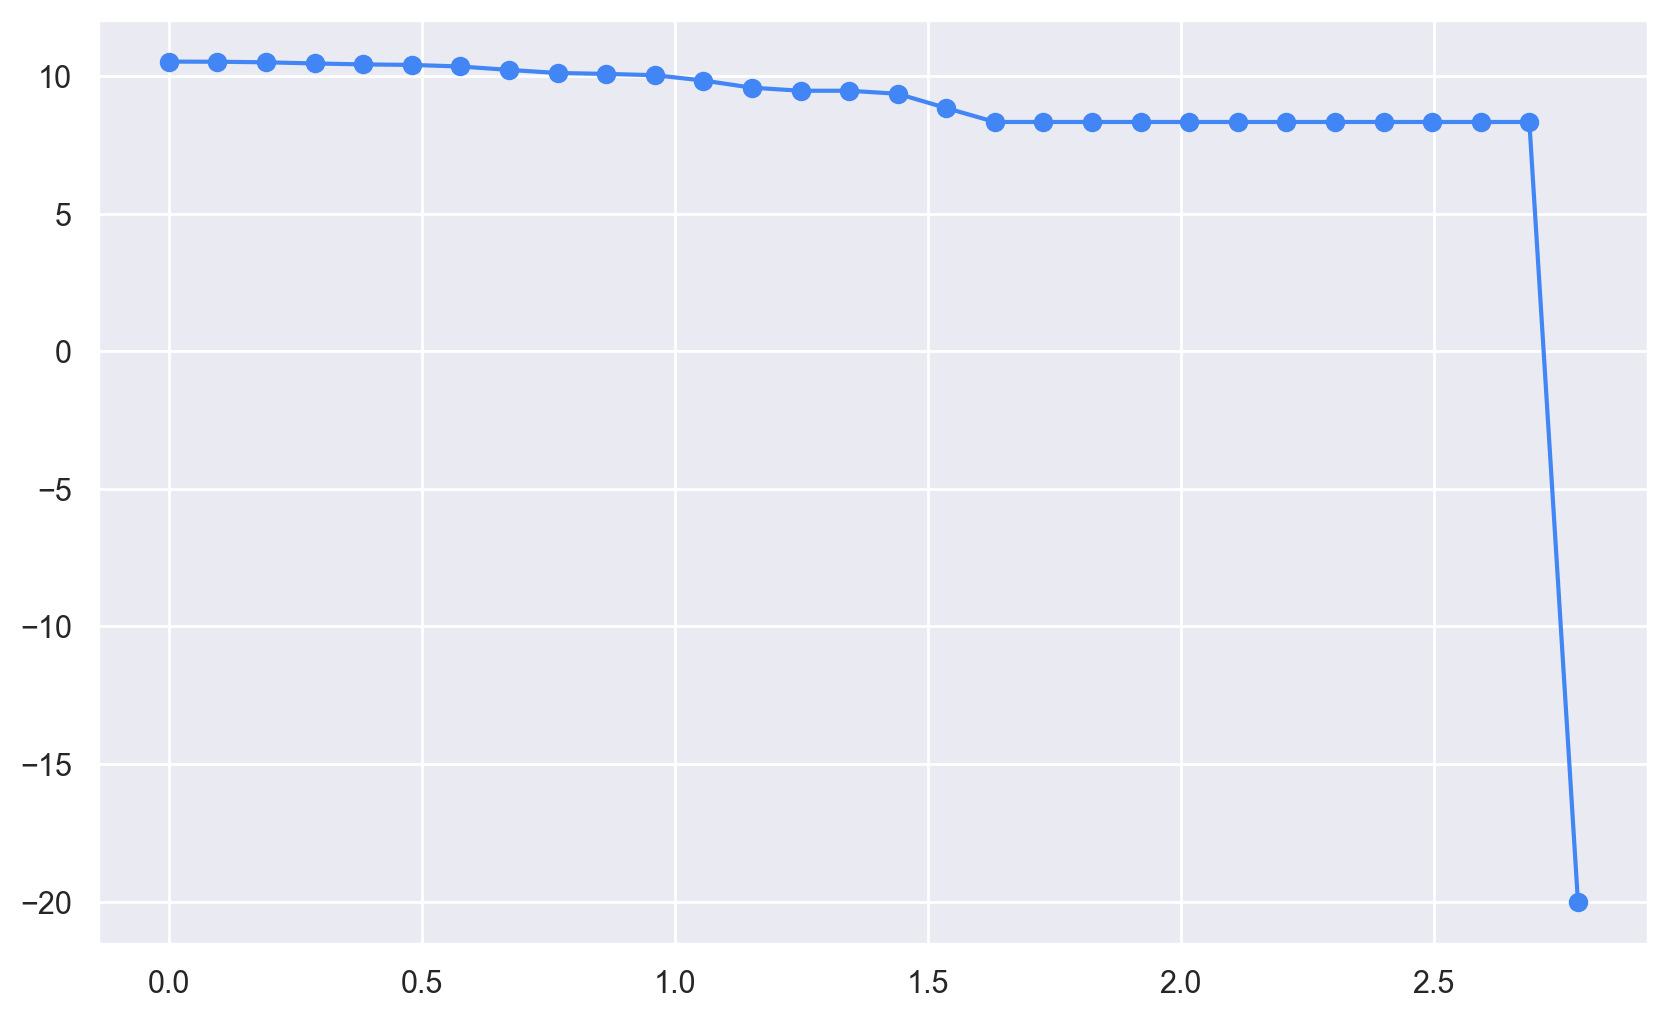

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(section_y, twist_current, marker="o")

Let's visualize our solution.

The following command does an in-place substitution of our VLM object, recursively evaluating all its fields from abstract values to concrete ones (i.e., NumPy arrays) at our solution, using our `sol` object.

In [25]:
# NBVAL_SKIP

vlm = sol(vlm)

In [26]:
# NBVAL_SKIP
from pyvista.trame.jupyter import launch_server
await launch_server().ready

vlm.draw()

Widget(value='<iframe src="http://localhost:58606/index.html?ui=P_0x20aed217e20_1&reconnect=auto" class="pyvis…

In [27]:
# chord_res = sol(chords)
# print(f"Chord values : {chord_res}")
twist = sol(twists)
print(f"Twist distribution (deg) : {twist}")
alpha_res = sol(alpha)
print(f"Angle of attack : {alpha_res:.3f} deg")
cl_res = sol(aero["CL"])
print(f"CL = {cl_res:.6f}")
cd_res = sol(aero["CD"])
print(f"CD = {cd_res:.6f}")

Twist distribution (deg) : [11.07639357 11.0589641  11.0335083  11.00665155 10.9703525  10.91684743
 10.84630637 10.76073342 10.66588176 10.56751355 10.45611892 10.31183222
 10.14076227  9.9813686   9.84067311  9.65439619  9.37803588  9.09231673
  8.90378353  8.73838996  8.39599709  7.89610277  7.39611604  6.89612394
  6.39613697  6.39609703  6.39609473  6.39609377  6.39609322  6.39609274]
Angle of attack : 0.000 deg
CL = 1.000000
CD = 0.054637


Text(0.5, 1.0, 'Optimized Twist Distribution')

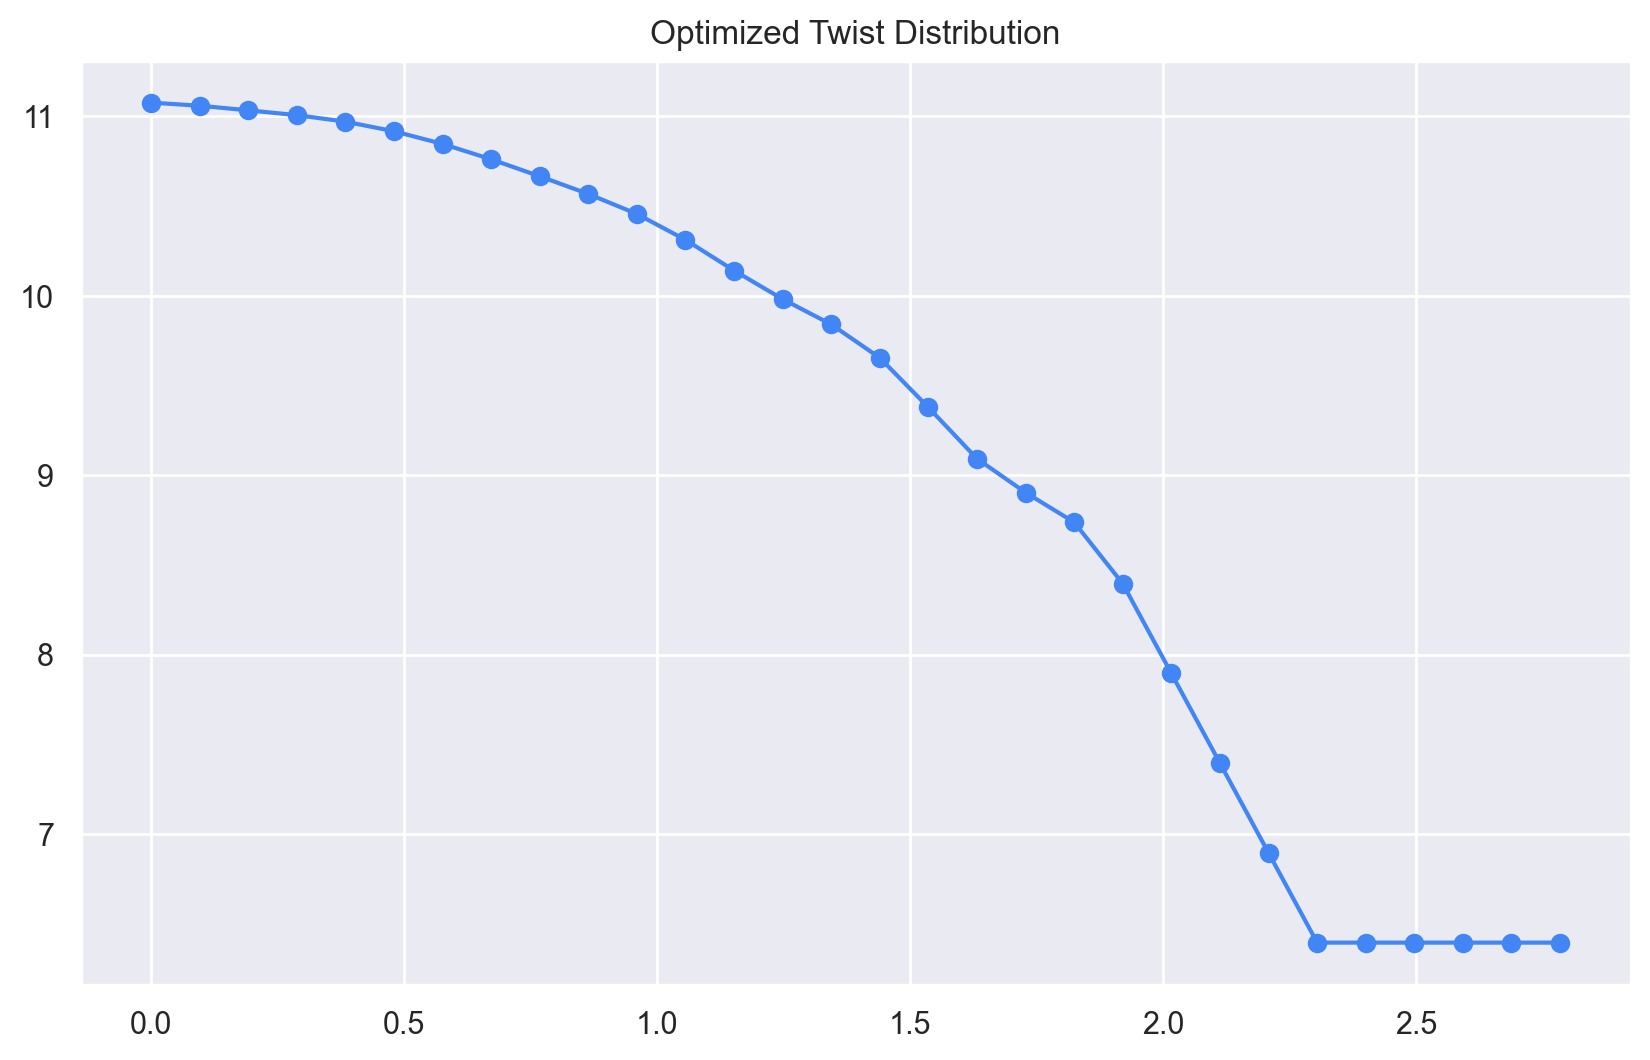

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(section_y, twist, marker="o")
plt.title("Optimized Twist Distribution")

Looking at our optimized solution, we can compare it to our known analytic solution (an elliptical lift distribution).

NameError: name 'chords' is not defined

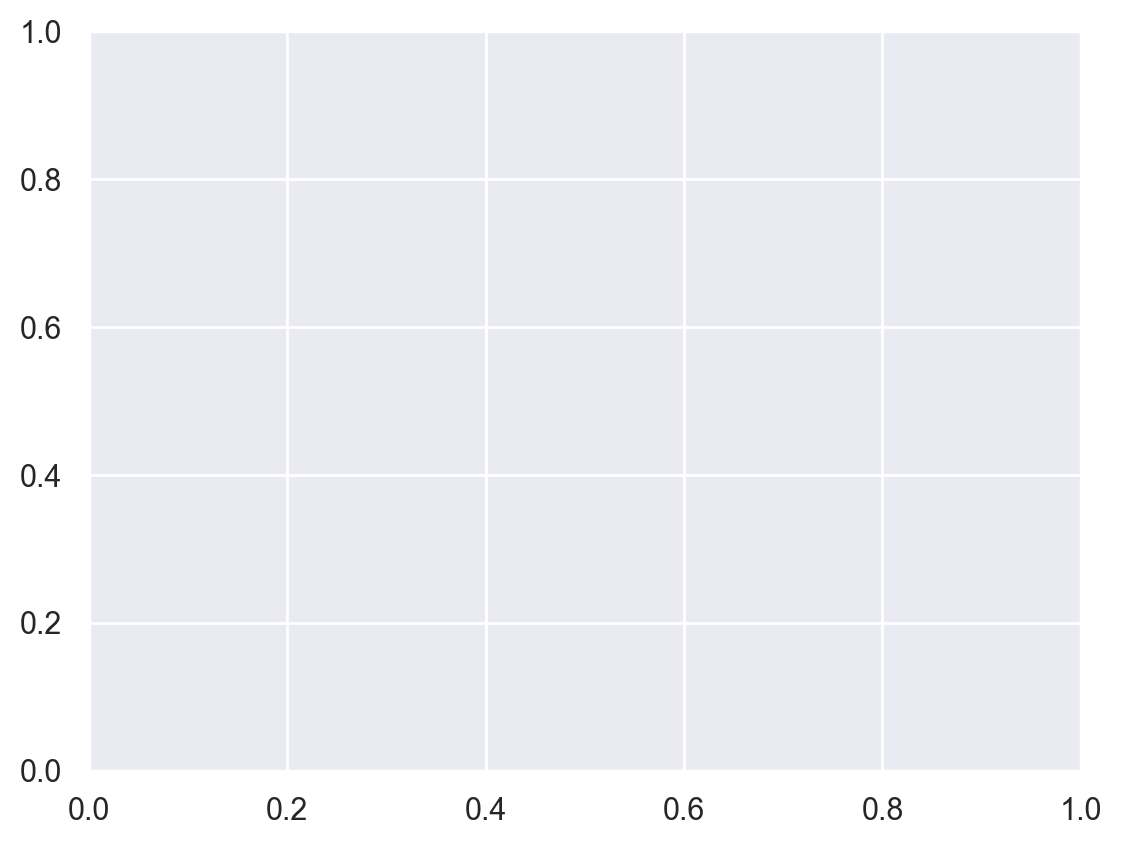

In [ ]:
# NBVAL_SKIP

import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p

fig, ax = plt.subplots()
plt.plot(
    section_y,
    sol(chords),
    ".-",
    label="AeroSandbox VLM Result",
    zorder=4,
)
y_plot = np.linspace(0, 1, 500)
plt.plot(
    y_plot,
    (1 - y_plot**2) ** 0.5 * 4 / np.pi * 0.125,
    label="Elliptic Distribution",
)
p.show_plot(
    "AeroSandbox Drag Optimization using VortexLatticeMethod", "Span [m]", "Chord [m]"
)

Slight differences arise due to numerical discretization, but it's convergent to the right answer. We can also check the objective function (the induced drag at the minimum):

In [36]:
# NBVAL_SKIP

AR = 2**2 / 0.25
CL = 1

CDi_theory = CL**2 / (np.pi * AR)
CDi_computed = sol(aero["CD"])
print(f"CDi (theory)   : {CDi_theory:.4f}")
print(f"CDi (computed) : {CDi_computed:.4f}")

RuntimeError: Error in Opti::value [OptiNode] at .../casadi/core/optistack.cpp:233:
.../casadi/core/optistack_internal.cpp:653: Unknown: Opti decision variable 'opti0_x_3' of shape 1x1, belonging to a different instance of Opti.

Essentially matching theory. Both theory and computation are expected to have slight errors compared to the exact potential flow solution:

* The theory side has small errors due to small-angle approximations and simplification of 3D chordwise effects near the tips
* The computational side has small errors due to numerical discretization.

(Both methods neglect thickness effects, too.)